__Markus Mulvihill__

__Last updated May 2026__

# Necessary Packages and Modules

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Introduction
The goal of this file is to demonstrate the limitations of the integral parameter estimation used to calculate insulin sensitivity $S_I$

In [2]:
try:
    SI_ests_01 = np.load("../scripts/variables/SI_ests_01.npy")
    SI_est_error_01 = np.load("../scripts/variables/SI_est_error_01.npy")
    meas_noise_std_01 = np.load("../scripts/variables/meas_noise_std_01.npy")
    print("Loaded variables")
except Exception:
    print("Run 01_Integral_Estimation.py")

Loaded variables


# Plot Results
+ The distribution of $\,SI$ estimates will be plotted over time
+ The MARD (90% CI) error will be plotted along for each measurement noise std $\sigma$

In [3]:
mean_err = np.mean(SI_est_error_01, axis=1)
mean_SI = np.mean(SI_ests_01, axis=1)
ci_low = np.percentile(SI_est_error_01, 5, axis=1)
ci_high = np.percentile(SI_est_error_01, 95, axis=1)
time = 60 * np.arange(mean_err.shape[1])

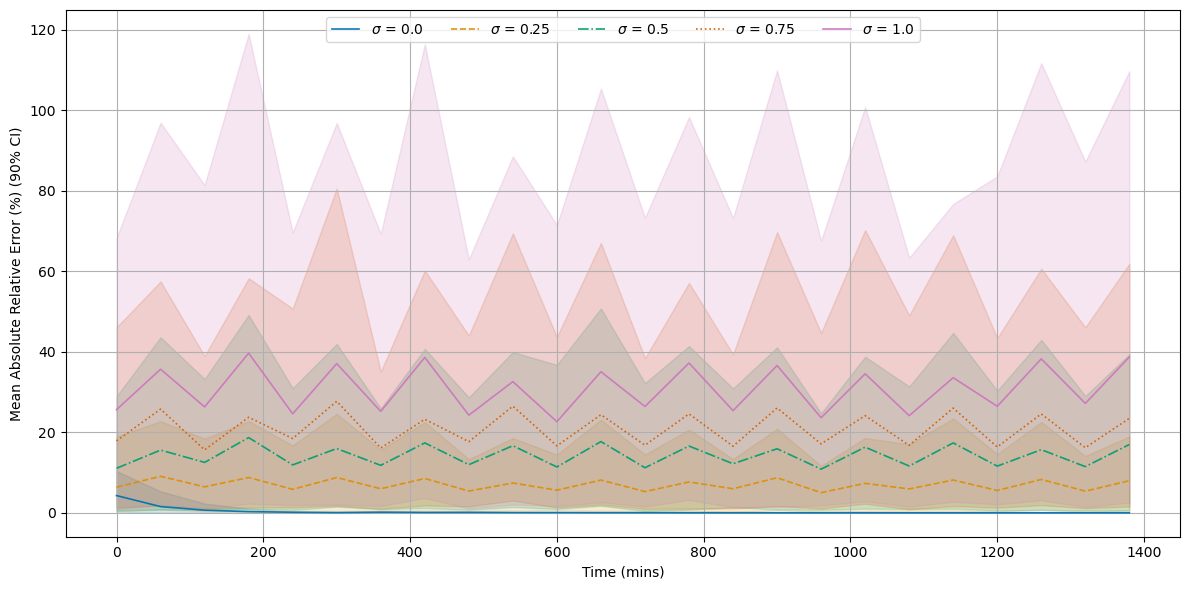

In [4]:
num_plots = mean_err.shape[0]
palette = sns.color_palette("colorblind", num_plots)

fig, ax = plt.subplots(figsize=(12, 6))
for i in range(num_plots):
    ax.plot(
        time,
        mean_err[i, :],
        color=palette[i],
        linewidth=1.2,
        alpha=0.95,
        linestyle=["-", "--", "-.", ":"][i % 4],
        label=f"$\\sigma$ = {meas_noise_std_01[i]}",
    )
    ax.fill_between(time, ci_low[i, :], ci_high[i, :], color=palette[i], alpha=0.18)

ax.legend(loc="upper center", ncols=num_plots)
ax.set_xlabel("Time (mins)")
ax.set_ylabel("Mean Absolute Relative Error (%) (90% CI)")
ax.grid()
fig.tight_layout()